# Лабораторная работа №5 
# Анализ алгоритмов декодирования Viterbi и MAP BCJR

## Описание:
В данной лабораторной работе предлагается исследовать алгоритмы декодирования на `решетке` - `Витерби` и `MAP BCJR`.

## Ход работы:

### Модель системы:
Пусть передается кодовая последовательность $\mathbf{x} = (x_1, x_2, \dots, x_N)$, модулированная с использованием BPSK ($0 \to +1, 1 \to -1$). Канал связи — аддитивный белый гауссовский шум (АБГШ).

Принятый сигнал:
$$ y_k = x_k + n_k, \quad n_k \sim \mathcal{N}(0, \sigma^2) $$

Задача декодера — восстановить исходную информационную последовательность.

Сравнивать алгоритмы будем при помощи метрик `BER` (Bit Error Rate) и `FER` (Frame Error Rate).

### Основные инструменты:

Настройка параметров, а также генерация решетки. Используется сверточное кодирование с $R = 1/2, K = 3$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # for showing progress during execution

# Model params
N_BITS = 1000          # bits in block
N_BLOCKS = 100          # blocks num
EbN0_dB_range = np.arange(0, 8, 1)

# Trellis def for code [7, 5] (octal) -> (1+D+D^2, 1+D^2)
# States: 00(0), 10(2), 01(1), 11(3)
TRELLIS = {}

for s in range(4):
    # s is [b_{k-1}, b_{k-2}]
    b1 = (s >> 1) & 1
    b2 = s & 1
    TRELLIS[s] = {}
    for input_bit in [0, 1]:
        # Next state: [input_bit, b_{k-1}]
        next_s = ((input_bit << 1) | b1) & 3 
        
        # Output polynoms
        out1 = input_bit ^ b1 ^ b2
        out2 = input_bit ^ b2
        
        # BPSK mapping: 0 -> +1, 1 -> -1
        bpsk_out = np.array([1 if x == 0 else -1 for x in [out1, out2]])
        
        TRELLIS[s][input_bit] = (next_s, bpsk_out)

print("Trellis was successfully created.")


Trellis was successfully created.


Функции вызова кодирования и добавления АБГШ:

In [2]:
def encode_conv(bits):
    state = 0
    encoded = []

    bits = np.concatenate([bits, [0, 0]]) # for correct termination
    
    for b in bits:
        next_s, out = TRELLIS[state][b]
        encoded.extend(out)
        state = next_s
    return np.array(encoded)

def awgn_channel(signal, eb_n0_db, rate=0.5): # adding some noise
    snr_lin = 10 ** (eb_n0_db / 10.0)
    sigma = np.sqrt(1.0 / (2 * rate * snr_lin))
    noise = np.random.randn(len(signal)) * sigma
    return signal + noise, sigma


### Алгоритмы декодирования:

#### 1. Алгоритм Витерби (ML - Maximum Likelihood)
Алгоритм Витерби ищет кодовое слово, которое минимизирует вероятность ошибки всего сообщения (Frame Error Rate, FER). Он находит путь в решетке кода, который имеет минимальное расстояние (или максимальную корреляцию) с принятым сигналом.

**Принцип работы:**
1.  Вычисляются метрики переходов (Branch Metrics) для каждого ребра решетки:
    $$ \gamma_k(s', s) = \sum_{i} (y_{k,i} \cdot x_{k,i}) $$
2.  На каждом шаге для каждого состояния $s$ выбирается единственный путь с максимальной метрикой:
    $$ \Lambda_{k+1}(s) = \max_{s'} (\Lambda_k(s') + \gamma_k(s', s)) $$
3.  Производится обратный проход (Traceback) по сохраненным указателям для восстановления лучшего пути.

Стоит заметить, что алгоритм принимает жесткое решение, т.е. выбирает строго либо 0, либо 1.

In [3]:
# Viterbi decoder with soft input, hard output
def viterbi_decoder(received, sigma):
    n_bits = len(received) // 2
    n_states = 4
    
    path_metrics = np.full((n_bits + 1, n_states), -1e9)
    path_metrics[0, 0] = 0
    
    paths = np.zeros((n_bits, n_states), dtype=int)
    
    # Running straight
    for t in range(n_bits):
        r_pair = received[2*t : 2*t+2]
        
        for s in range(n_states):
            if path_metrics[t, s] < -1e8: continue
            
            for input_bit in [0, 1]:
                next_s, out_syms = TRELLIS[s][input_bit]
                
                branch_metric = (r_pair[0]*out_syms[0] + r_pair[1]*out_syms[1])
                
                new_metric = path_metrics[t, s] + branch_metric
                
                if new_metric > path_metrics[t+1, next_s]:
                    path_metrics[t+1, next_s] = new_metric
                    paths[t, next_s] = s
                    
    # Running back
    decoded_bits = np.zeros(n_bits, dtype=int)
    
    current_state = np.argmax(path_metrics[n_bits])
    
    for t in range(n_bits - 1, -1, -1):
        prev_state = paths[t, current_state]
        
        bit_val = 0
        if TRELLIS[prev_state][1][0] == current_state:
            bit_val = 1
        
        decoded_bits[t] = bit_val
        current_state = prev_state
        
    return decoded_bits


#### 2. Алгоритм BCJR (MAP - Maximum A Posteriori)
Алгоритм BCJR минимизирует вероятность ошибки каждого отдельного бита (Bit Error Rate, BER). Вместо поиска одного пути, он оценивает вероятность того, что бит $u_k$ был равен 0 или 1, учитывая весь принятый сигнал (прошлое и будущее).

**Принцип работы (Log-MAP):**
Алгоритм вычисляет логарифмическое отношение правдоподобия (LLR) для каждого бита:
$$ L(u_k) = \ln \frac{P(u_k=1 | \mathbf{y})}{P(u_k=0 | \mathbf{y})} $$

Для этого выполняются три этапа:
1.  **Прямой проход (Forward Recursion, $\alpha$):** Вероятность попасть в состояние $s$ на шаге $k$, учитывая сигнал до этого момента.
    $$ \alpha_{k}(s) = \max_{s'} (\alpha_{k-1}(s') + \gamma_k(s', s)) $$
2.  **Обратный проход (Backward Recursion, $\beta$):** Вероятность получить остаток сигнала после момента $k$, исходя из состояния $s$.
    $$ \beta_{k}(s) = \max_{s'} (\beta_{k+1}(s') + \gamma_{k+1}(s, s')) $$
3.  **Вычисление LLR:** Объединение $\alpha$, $\beta$ и $\gamma$ для принятия решения.

Операция $\max(a, b) = \max(a, b) + \ln(1 + e^{-|a-b|})$.

Этот алгоритм принимает мягкое решение (вещ. число LLR), хотя и имеет более высокую вычислительную сложность, так как требует прохода в обе стороны. В нашем случае, однако, мы все равно ставим в конце жесткий выбор 0 или 1 для подсчета метрик. Мягкость решения может использоваться в итеративных схемах декодирования, например в турбо-кодах.

In [4]:
def bcjr_decoder(received, sigma):
    n_bits = len(received) // 2
    n_states = 4

    # Alpha (forward), Beta (backward)
    alpha = np.full((n_bits + 1, n_states), -1e9)
    beta = np.full((n_bits + 1, n_states), -1e9)
    
    alpha[0, 0] = 0
    beta[n_bits, 0] = 0
    
    noise_var = sigma**2
    Lc = 2 / noise_var # channel reliability factor for BPSK
    
    gamma = np.zeros((n_bits, n_states, 2))
    
    for t in range(n_bits):
        r_pair = received[2*t : 2*t+2]
        for s in range(n_states):
            for bit in [0, 1]:
                _, out_syms = TRELLIS[s][bit]
                
                metric = 0.5 * Lc * (r_pair[0]*out_syms[0] + r_pair[1]*out_syms[1])
                
                gamma[t, s, bit] = metric

    # 1. Forward Recursion (Alpha)
    for t in range(n_bits):
        for s in range(n_states):
            if alpha[t, s] < -1e8: continue
            for bit in [0, 1]:
                next_s, _ = TRELLIS[s][bit]

                alpha[t+1, next_s] = np.logaddexp(alpha[t+1, next_s], 
                                                  alpha[t, s] + gamma[t, s, bit])
                
    # 2. Backward Recursion (Beta)
    for t in range(n_bits - 1, -1, -1):
        for s in range(n_states):
            for bit in [0, 1]:
                next_s, _ = TRELLIS[s][bit]
                if beta[t+1, next_s] < -1e8: continue
                
                beta[t, s] = np.logaddexp(beta[t, s], 
                                          gamma[t, s, bit] + beta[t+1, next_s])

    # 3. LLR Calculation
    L_out = np.zeros(n_bits)
    for t in range(n_bits):
        # L(u_k) = log( P(u=1) / P(u=0) )
        prob_1 = -1e9
        prob_0 = -1e9
        
        for s in range(n_states):
            # Bit 0
            next_s0, _ = TRELLIS[s][0]
            path0 = alpha[t, s] + gamma[t, s, 0] + beta[t+1, next_s0]
            prob_0 = np.logaddexp(prob_0, path0)
            
            # Bit 1
            next_s1, _ = TRELLIS[s][1]
            path1 = alpha[t, s] + gamma[t, s, 1] + beta[t+1, next_s1]
            prob_1 = np.logaddexp(prob_1, path1)
            
        L_out[t] = prob_1 - prob_0
        
    return (L_out > 0).astype(int)


### Симуляция

In [5]:
ber_viterbi, ber_bcjr = [], []
fer_viterbi, fer_bcjr = [], []

print("Start modeling (BER + FER)...")

for snr in tqdm(EbN0_dB_range):
    bit_errors_v, bit_errors_b = 0, 0
    frame_errors_v, frame_errors_b = 0, 0
    
    total_bits = 0
    total_blocks = 0
    
    for _ in range(N_BLOCKS):
        # 1. Generation and encoding
        bits = np.random.randint(0, 2, N_BITS)
        encoded = encode_conv(bits)
        
        # 2. Channel
        received, sigma = awgn_channel(encoded, snr)
        
        # 3. Decoding
        decoded_v_full = viterbi_decoder(received, sigma)
        decoded_b_full = bcjr_decoder(received, sigma)
        
        # 4. Remove term. bits
        decoded_v = decoded_v_full[:-2]
        decoded_b = decoded_b_full[:-2]
        
        # 5. Errors analisys
        be_v = np.sum(bits != decoded_v)
        be_b = np.sum(bits != decoded_b)
        
        bit_errors_v += be_v
        bit_errors_b += be_b
        
        if be_v > 0: frame_errors_v += 1
        if be_b > 0: frame_errors_b += 1
        
        total_bits += N_BITS
        total_blocks += 1
        
    ber_viterbi.append(bit_errors_v / total_bits)
    ber_bcjr.append(bit_errors_b / total_bits)
    
    fer_viterbi.append(frame_errors_v / total_blocks)
    fer_bcjr.append(frame_errors_b / total_blocks)

print("Success.")


Start modeling (BER + FER)...


100%|█████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:35<00:00,  4.48s/it]

Success.


### Построение графиков

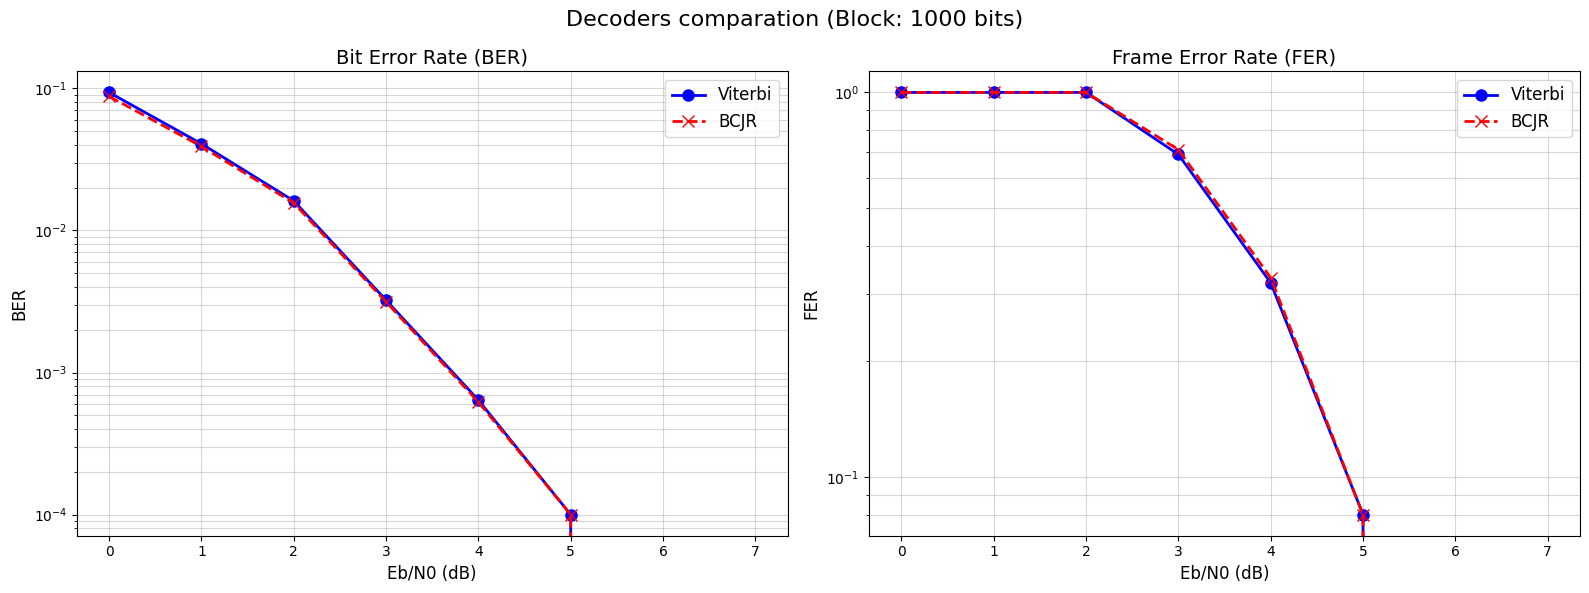

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: BER ---
ax1.semilogy(EbN0_dB_range, ber_viterbi, 'b-o', label='Viterbi', linewidth=2, markersize=8)
ax1.semilogy(EbN0_dB_range, ber_bcjr, 'r--x', label='BCJR', linewidth=2, markersize=8)

ax1.set_title('Bit Error Rate (BER)', fontsize=14)
ax1.set_xlabel('Eb/N0 (dB)', fontsize=12)
ax1.set_ylabel('BER', fontsize=12)
ax1.grid(True, which="both", ls="-", alpha=0.5)
ax1.legend(fontsize=12)
#ax1.set_ylim(1e-2, 1.0) 

# --- Plot 2: FER ---
ax2.semilogy(EbN0_dB_range, fer_viterbi, 'b-o', label='Viterbi', linewidth=2, markersize=8)
ax2.semilogy(EbN0_dB_range, fer_bcjr, 'r--x', label='BCJR', linewidth=2, markersize=8)

ax2.set_title('Frame Error Rate (FER)', fontsize=14)
ax2.set_xlabel('Eb/N0 (dB)', fontsize=12)
ax2.set_ylabel('FER', fontsize=12)
ax2.grid(True, which="both", ls="-", alpha=0.5)
ax2.legend(fontsize=12)
#ax2.set_ylim(0.85, 1.0) 

plt.suptitle(f'Decoders comparation (Block: {N_BITS} bits)', fontsize=16)
plt.tight_layout()
plt.show()


Хоть алгоритм Витерби и должен лучше отрабатывать по метрике FER, а BCJR - по BER, мы наблюдаем, что принципиальной разницы в случае нашей модели нет. Это можно объяснить тем, что при высоком отношении SNR наиболее вероятная последовательность будет состоять из битов с максимальной апостериорной вероятностью. Наглядную разницу можно получить путем уменьшения блока бит: тогда Витерби будет сильно ошибаться из-за краевых эффектов.

## Выводы:
В данной лабораторной работе мы исследовали алгоритмы декодирования `Витерби` и `MAP BCJR`. Была подготовлена модель, использующая сверточное кодирование и добавляющая гауссовский шум, имитируя передачу через канал связи. Моделирование показало, что алгоритмы `Витерби` и `BCJR` обеспечивают схожую помехоустойчивость (BER, FER), однако `BCJR` предоставляет дополнительную информацию о надежности битов ценой повышенной вычислительной сложности. В более сложных схемах, например в `турбо-кодах`, это позволяет итеративно корректировать результат для достижения лучшей точности.